# 

The purpose of this notebook is to practice using threeML by replicating the process discussed by J. Michael Burgess, described in his blog: 
https://jmichaelburgess.com/fits_files/

Last updated: 10-18-2025

In [ ]:
%matplotlib notebook
%matplotlib inline

import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
import numpy as np
from pathlib import Path

from astropy import units as u
from astropy.time import Time
from astropy.timeseries import TimeSeries
from astropy.table import Table

from specutils import Spectrum1D

from astromodels import Gaussian, Model, PointSource
from astromodels.functions import Constant

from padre_meddea.io.file_tools import read_raw_file
from padre_meddea.io.file_tools import read_file
import padre_meddea.calibration.calibration as calibration

from padre_meddea.util.pixels import PixelList
from padre_meddea.spectrum.spectrum import PhotonList
import padre_meddea.util.pixels as pixels
import padre_meddea.spectrum.calibration as cal

from threeML import *
from threeML import Model, PointSource, DataList, JointLikelihood, DispersionSpectrumLike

from threeML.utils.spectrum.binned_spectrum import BinnedSpectrumWithDispersion
from threeML.utils.OGIP.response import OGIPResponse

import warnings
warnings.filterwarnings("ignore", message="The current value of the parameter")
warnings.simplefilter("ignore")
np.seterr(all="ignore")

J. Michael Burgess uses sample data from the Fermi Gamma-ray Burst Monitor (GBM) that has been reduced from its non-standard format into OGIP compliant FITS files. In his tutorial (https://jmichaelburgess.com/fits_files/), he uses a file called 'example.pha'. The specific file that he uses is not known, and I have not been able to contact him at the email address or social media links provided on his website to ask.

This file, 'example.pha' must have been a Fermi GBM Daily Data Product, since such files are the only ones that are PHA FITS files. Extra steps are required to obtain these files, and additional software may be required to parse them. 

Here, I want to use the same method that the author describes and apply it to MeDDEA data instead. 3ML expects measurements to be in OGIP-compliant .pha format, or at least in a format in which counts, energy bins, and exposure (i.e. integration time) are clearly defined. 

Read in the data (Ba133 source, -20C calibration data). This dataset has had the microphonics aggressively clipped out, includes single events only. The arrays should be clipped to match the energy bounds of the DRM from Olivier, which are from 4 to 150 keV. 

In [13]:
# Load the event_list data.
data_dir = Path(r"/Users/labadmin/Desktop/data")

table = Table.read(data_dir / "ba133_event_list_1kevto110kev_single_events_bl_sub.fits")

# Convert plain float JD column to Time object
jd = table["time"].data  # Just a 1D array of JD floats
time_col = Time(jd, format="jd", scale="utc")

# Remove 'time' column so it's not duplicated
table.remove_column("time")

# Create TimeSeries
event_list = TimeSeries(data=table, time=time_col)

(array([0., 0., 0., ..., 0., 0., 0.], shape=(1509,)),
 array([0.000e+00, 1.000e-01, 2.000e-01, ..., 1.507e+02, 1.508e+02,
        1.509e+02], shape=(1510,)),
 [<matplotlib.patches.Polygon at 0x15248b9d0>])

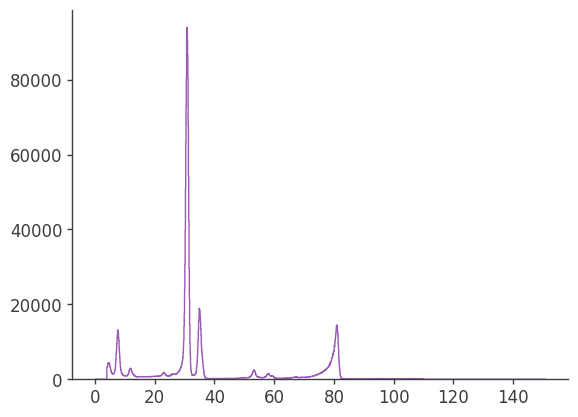

In [ ]:
%matplotlib inline
plt.hist(event_list['energy'][event_list['energy']>4.], bins=np.arange(0,151,0.1), histtype='step') # match the energy bounds in the DRM, 4 keV lower bound.

Unlike the tutorial, we do not have a .rsp detector response file for MeDDEA, but we do have separate ARF and RMF files, each in an OGIP-compliant fits format. We can use these to construct the DRM. 

In [15]:
arf_file = "MeDDEA_ARF.arf"
rmf_file = "MeDDEA_RMF.rmf"

rsp = OGIPResponse(rmf_file, arf_file)
arf = rsp.arf
rmf = rsp.rmf
drm = rsp.matrix

Because the measured data will be compared to the folded counts (source model convolved with the DRM), rebin the measured data to match the energy range and energy bins of the DRM. 

In [16]:
def rebin_spec(event_list, rsp, num_bins, plot=None):
    """
    Rebin photon data to match the dimensions of the DRM. 

    Parameters:
    -----------
    event_list: object
        The photon list to rebin and plot.

    rsp: object
        OGIP compliant detector response.

    num_bins: int
        The number of energy bins in the rebinned counts vs. energy bins histogram.

    plot: boolean
        If True, plot the rebinned spectrum.

    Returns:
    --------
    hist: counts
        The counts per energy bin of the rebinned spectrum.

    bin_centers: array
        The locations of the centers of the energy bins.

    energy_min: array
        The lower edge of each energy bin.

    energy_max: array
        The upper edge of each energy bin.

    spectrum: Spectrum1D
        The rebinned spectrum.
    """

    # Compute uniform bin width exactly
    e_min = rsp.monte_carlo_energies[0]
    e_max = rsp.monte_carlo_energies[-1]
    bin_width = (e_max - e_min) / num_bins

    # Create bin edges explicitly to avoid floating-point drift
    bin_edges = e_min + bin_width * np.arange(num_bins + 1)

    energies = event_list["energy"]

    # Histogram the photon energies
    hist, _ = np.histogram(energies, bins=bin_edges)

    # Compute bin centers
    bin_centers = 0.5 * (bin_edges[:-1] + bin_edges[1:])
    energy_min = bin_edges[:-1]
    energy_max = bin_edges[1:]

    # Create Spectrum1D object
    spectrum = Spectrum1D(
        flux=hist * u.ct,  # counts per bin
        spectral_axis=bin_centers * u.keV
    )

    if plot:
        plt.step(bin_centers, hist, where="mid")
        plt.xlabel("Energy (keV)")
        plt.ylabel("Counts")
        plt.title("Measured Spectrum (Rebinned)")
        plt.grid()
        plt.show()

    return hist, bin_centers, energy_min, energy_max, spectrum

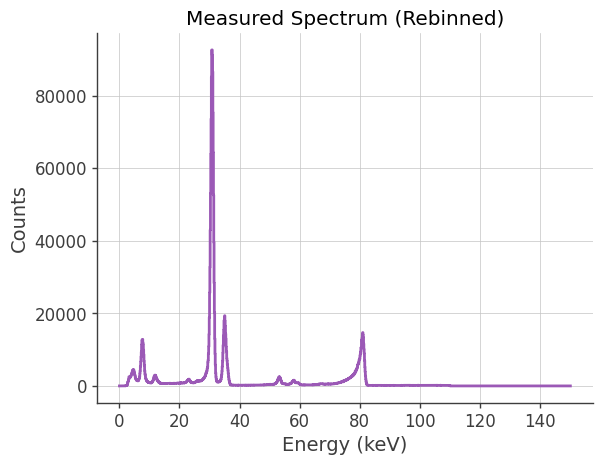

In [17]:
%matplotlib inline
hist, bin_centers, energy_min, energy_max, cal_spec = rebin_spec(
    event_list, rsp, num_bins=1500, plot=True
)

Great! the data have been rebinned, and the spectrum looks like what we expect. 

This is a Barium 133 spectrum measured by MeDDEA. We cannot simply apply the DRM to this spectrum however, because this spectrum includes detector effects! What we need to do is to create a model Barium 133 spectrum to which we can apply the DRM and fit the convolved result to the measured result. 

In [18]:
def plot_drm(rmf_file, arf_file, plot=None):

    response = OGIPResponse(rmf_file, arf_file)

    ebounds_centers = (
        response.ebounds[:-1] + response.ebounds[1:]
    ) / 2.0  # centers of the measured energy bins
    mc_energies_centers = (
        response.monte_carlo_energies[:-1] + response.monte_carlo_energies[1:]
    ) / 2.0  # centers of the true energy bins

    drm = response.matrix

    if plot == True:
        fig, ax = plt.subplots(1, 1, figsize=(5, 4))

        im = ax.pcolormesh(
            ebounds_centers,
            mc_energies_centers,
            drm.T,
            norm=LogNorm(vmin=1e-6, vmax=1),
            cmap="viridis",
        )

        ax.set_xlabel("Measured Energy [keV]")
        ax.set_ylabel("Photon Energy [keV]")
        ax.set_title("Reconstructed DRM")

        colorbar = fig.colorbar(im, ax=ax)
        colorbar.set_label("Instrument Response")
        plt.savefig("rmf_from_threeml.png", dpi=150)
        plt.show()

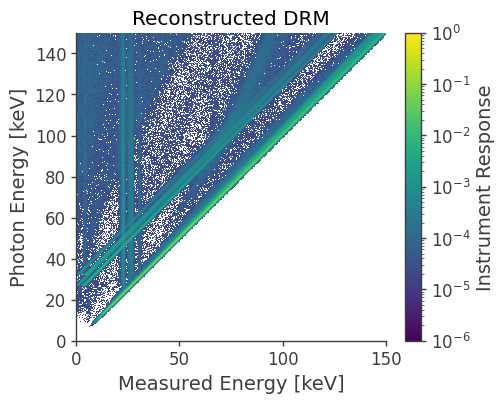

In [19]:
plot_drm(rmf_file, arf_file, plot=True)

Extract the Monte Carlo or photon energies and take their mean.

In [20]:
mean_mc_energy = np.mean(
    np.vstack((rsp.monte_carlo_energies[:-1], rsp.monte_carlo_energies[1:])).T, axis=1
)

To find the true spectrum, we use a forward folding technique:

1. assume a photon model spectrum with a set a variable parameters
2. convolve this spectrum with the instrument response to produce counts in energy space
3. compare these trial counts with the observed counts statistically
4. iterate until a convergence criterion is met.

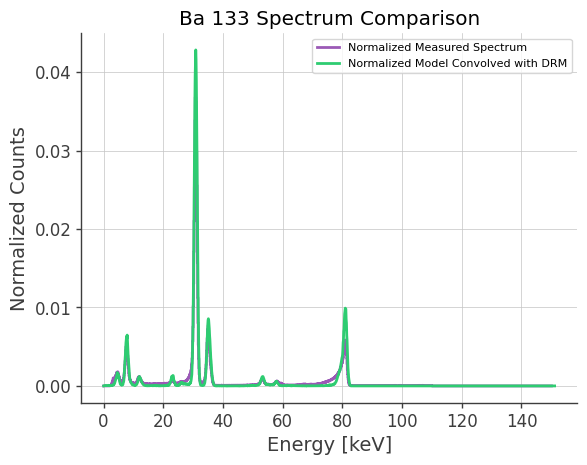

In [15]:
# Create a model of the source and convolve with the DRM.

# Incident photon energy bins (model)
energy_min_incident = rsp.monte_carlo_energies[:-1]
energy_max_incident = rsp.monte_carlo_energies[1:]
energy_centers_incident = 0.5 * (energy_min_incident + energy_max_incident)

# Detected energy bins (measured and folded spectrum)
energy_min_detected = rsp.ebounds[:-1]
energy_max_detected = rsp.ebounds[1:]
energy_centers_detected = 0.5 * (energy_min_detected + energy_max_detected)

# Define Ba133 source spectrum at incident photon bin centers
model_energies = np.zeros(len(energy_centers_incident))

# Ba133 line energies in keV (known precise values)
ba133_line_energies = np.array(
    [4.67355, 30.6254, 30.9731, 35.053, 35.9003, 53.1622, 79.6142, 80.998]
)
ba133_intensities = (
    np.array([15.87, 33.8, 62.4, 18.24, 4.45, 2.14, 2.63, 33.31]) / 100.0
)

# Find the closest bin index for each line energy in the incident energy bins
for line_energy, intensity in zip(ba133_line_energies, ba133_intensities):
    idx = np.abs(energy_centers_incident - line_energy).argmin()
    model_energies[idx] = intensity

# Convolve model with DRM
folded_counts = np.dot(model_energies, drm.T)

# Normalize
folded_counts_norm = folded_counts / np.sum(folded_counts)
hist_norm = hist / np.sum(hist)

# Plot measured (hist) vs folded model spectrum
plt.step(
    energy_centers_detected,
    hist_norm,
    where="mid",
    label="Normalized Measured Spectrum",
)
plt.plot(
    energy_centers_detected * 1.007,
    folded_counts_norm,
    label="Normalized Model Convolved with DRM",
)
# for this_line in ba133_line_energies:
#    plt.axvline(this_line)
plt.title("Ba 133 Spectrum Comparison")
plt.xlabel("Energy [keV]")
plt.ylabel("Normalized Counts")
plt.legend()
plt.grid()
plt.show()

Now, switching to 3ML... 

3ML does not have built-in support for Diraq delta functions. Instead, delta functions can be modelled using very narrow Gaussian distributions... 

In [ ]:
def fit_spec(event_list, hist, rsp, int_time, initial_background, plot_fit=None, plot_residuals=None): 
    # Define the measured spectrum
    hist, bin_centers, energy_min, energy_max, cal_spec = rebin_spec(event_list, 
                                                                     rsp, 
                                                                     num_bins=np.shape(rsp.matrix)[0], 
                                                                     plot=False)

    # Create observed spectrum. 
    # Since our spectrum data is not in the standard OGIP format (i.e. not a PHA file), we can use the following method instead.
    # Define a wrapper that contains the measured Ba133 spectrum.

    obs_spectrum = BinnedSpectrumWithDispersion(
        counts=hist, # normalized measurement
        exposure=int_time,
        response=rsp,
    )
    obs_spectrum._errors = np.ones_like(hist)

    # Set up plugin. 
    # The DispersionSpectrumLike plugin expects the background to be an instance of threeML.data_spectrum.BinnedSpectrum. 
    # The "background" argument in the following plugin is intended for actual background measurements, not functions. 
    # Currently, "background" is defined as a constant function.
    plugin = DispersionSpectrumLike(
        name="Ba133_Measured_Spectrum",
        observation=obs_spectrum,
        background=None,
        verbose=False,
    )

    # Define the model to use. 
    # Define a constant background.
    background = Constant()
    background.k.value = initial_background
    background.k.bounds = (0, None)
    background.k.free = True

    # Define the Ba133 spectral emission lines.
    ba133_lines_keV = np.array([4.7, 30.6, 31.0, 35.1, 35.9, 53.2, 79.6, 81.5])  # in keV
    ba133_intensities = np.array([15.87, 33.8, 62.4, 18.24, 4.45, 2.14, 2.63, 33.31]) / 100.0

    ba133_lines = []
    for i, (this_energy, this_intensity) in enumerate(zip(ba133_lines_keV, ba133_intensities)):
        line = Gaussian()
        line.mu.value = this_energy
        line.mu.fixed = True

        line.sigma.value = 0.01  # Approximate Dirac delta with very narrow Gaussian
        line.sigma.fixed = True

        line.F.value = this_intensity # TODO: need to update. astromodels "F" is not simply the amplitude of the peak. 3ML does rescale in its algorithms. 
        line.F.bounds = (0, None)
        line.F.free = True

        ba133_lines.append(line)

    # Combine the background and the spectral emission lines with the background.
    total_model = background
    for this_line in ba133_lines: 
        total_model += this_line

    # Create source and model
    source = PointSource("Ba133_Source_Spectrum", ra=0, dec=0, spectral_shape=total_model)
    model = Model(source)

    # Likelihood fit
    data_list = DataList(plugin)
    jl = JointLikelihood(model, data_list)

    fit_result = jl.fit(quiet=False)

    # Bayesian sampling (optional).
    if hasattr(jl, "sample"):
        print("➡ Running Bayesian sampling with emcee...")
        fit_result = jl.sample("emcee", nwalkers=50, burn_in=200, steps=1000)

    # Plot the best-fit spectrum and residuals.
    model_counts = plugin.get_model()

    if plot_fit:
        plt.figure(figsize=(10, 6))
        plt.scatter(bin_centers[:-1], hist[:-1], c='blue', s=0.8, label="Measured Spectrum")
        plt.plot(bin_centers[:-1], model_counts[:-1], color='red', linewidth=0.8, label="Best-fit Spectrum")
        
        for this_line in ba133_lines_keV:
            plt.axvline(this_line, color='gray', linewidth=0.8, linestyle='--', alpha=0.4)
        plt.xlabel("Energy (keV)")
        plt.ylabel("Counts")
        plt.title("Ba-133 Spectrum Fit with 3ML")
        plt.legend()
        plt.xlim(0, 100)
        plt.show()

    if plot_residuals:
        residuals = hist[:-1] - model_counts[:-1].value
        plt.figure()
        plt.scatter(bin_centers[:-1], residuals, s=2.0)
        plt.axhline(0, color='black', linestyle='--')
        plt.xlabel("Energy (keV)")
        plt.ylabel("Residuals")
        plt.title("Fit Residuals")
        plt.xlim(0, 100)
        plt.show()

        plt.hist(residuals, bins=30, edgecolor='black')
        plt.title('Best-Fit Residuals')
        plt.xlabel('Residuals')
        plt.show()

    return fit_result

07:56:43 INFO      Auto-probed noise models:                                                    ]8;id=981985;file:///Users/labadmin/opt/anaconda3/envs/threeml_py310/lib/python3.10/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=668225;file:///Users/labadmin/opt/anaconda3/envs/threeml_py310/lib/python3.10/site-packages/threeML/plugins/SpectrumLike.py#490\490]8;;\

         INFO      - observation: gaussian                                                      ]8;id=657077;file:///Users/labadmin/opt/anaconda3/envs/threeml_py310/lib/python3.10/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=96179;file:///Users/labadmin/opt/anaconda3/envs/threeml_py310/lib/python3.10/site-packages/threeML/plugins/SpectrumLike.py#491\491]8;;\

         INFO      - background: None                                                           ]8;id=917912;file:///Users/labadmin/opt/anaconda3/envs/threeml_py310/lib/python3.10/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=99718;file:///Users/labadmin/opt/anaconda3/envs/threeml_py310/lib/python3.10/site-packages/threeML/plugins/SpectrumLike.py#492\492]8;;\

         INFO      set the minimizer to minuit                                             ]8;id=526002;file:///Users/labadmin/opt/anaconda3/envs/threeml_py310/lib/python3.10/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=706674;file:///Users/labadmin/opt/anaconda3/envs/threeml_py310/lib/python3.10/site-packages/threeML/classicMLE/joint_likelihood.py#1046\1046]8;;\

07:56:50 WARNING   69.54 percent of samples have been thrown away because they failed the  ]8;id=35849;file:///Users/labadmin/opt/anaconda3/envs/threeml_py310/lib/python3.10/site-packages/threeML/analysis_results.py\analysis_results.py]8;;\:]8;id=258951;file:///Users/labadmin/opt/anaconda3/envs/threeml_py310/lib/python3.10/site-packages/threeML/analysis_results.py#1739\1739]8;;\
                  constraints on the parameters. This results might not be suitable for                            
                  error propagation. Enlarge the boundaries until you loose less than 1                            
                  percent of the samples.                                                                          

...

1.00,-0.00,0.00,0.00,-0.03,-0.01,-0.03,-0.02,0.02,-0.02,0.01,-0.02,-0.01,0.17,0.18,-0.16,-0.03,-0.02,-0.04,-0.25,0.08,-0.16,-0.01,0.02,0.02
-0.00,1.00,0.46,0.46,-0.00,-0.00,-0.00,-0.00,0.00,-0.00,-0.00,0.00,0.00,-0.00,-0.00,0.00,0.00,0.00,0.00,0.00,-0.00,0.00,0.00,-0.00,-0.00
0.00,0.46,1.00,-0.45,0.00,0.00,0.00,0.00,-0.00,0.00,0.00,-0.00,-0.00,0.00,0.00,-0.00,-0.00,-0.00,-0.00,-0.00,0.00,-0.00,-0.00,0.00,0.00
0.00,0.46,-0.45,1.00,0.00,0.00,0.00,0.00,-0.00,0.00,0.00,-0.00,-0.00,0.00,0.00,-0.00,-0.00,-0.00,-0.00,-0.00,0.00,-0.00,-0.00,0.00,0.00
-0.03,-0.00,0.00,0.00,1.00,-0.41,-0.51,0.00,-0.00,0.00,-0.00,0.00,0.00,-0.00,-0.00,0.00,0.00,-0.00,0.00,0.01,-0.00,0.00,0.00,-0.00,-0.00
-0.01,-0.00,0.00,0.00,-0.41,1.00,-0.43,-0.01,0.01,-0.01,-0.00,0.00,0.00,-0.00,-0.00,0.00,-0.01,0.01,-0.01,0.00,-0.00,0.00,0.00,-0.00,-0.00
-0.03,-0.00,0.00,0.00,-0.51,-0.43,1.00,0.00,-0.00,0.00,-0.00,0.00,0.00,-0.00,-0.00,0.00,0.00,0.00,0.00,0.01,-0.00,0.00,0.00,-0.00,-0.00
-0.02,-0.00,0.00,0.00,0.00,-0.01,0.00,1.00,0.41,-0.49,-0.00,0.00,0.00,-0.00,-0.00,0.00,0.00,-0.01,0.00,0.01,-0.00,0.00,0.00,-0.00,-0.00
0.02,0.00,-0.00,-0.00,-0.00,0.01,-0.00,0.41,1.00,0.46,0.00,-0.00,-0.00,0.00,0.00,-0.00,-0.00,0.01,-0.00,-0.01,0.00,-0.00,-0.00,0.00,0.00
-0.02,-0.00,0.00,0.00,0.00,-0.01,0.00,-0.49,0.46,1.00,-0.00,0.00,0.00,-0.00,-0.00,0.00,0.00,-0.01,0.00,0.00,-0.00,0.00,0.00,-0.00,-0.00
0.01,-0.00,0.00,0.00,-0.00,-0.00,-0.00,-0.00,0.00,-0.00,1.00,0.44,0.36,0.15,0.16,-0.13,-0.00,-0.00,-0.00,-0.00,0.00,-0.00,-0.00,0.00,0.00


Values of -log(likelihood) at the minimum:

,-log(likelihood)
Ba133_Measured_Spectrum,99.977723
total,99.977723


Values of statistical measures:

,statistical measures
AIC,250.837399
BIC,382.785955


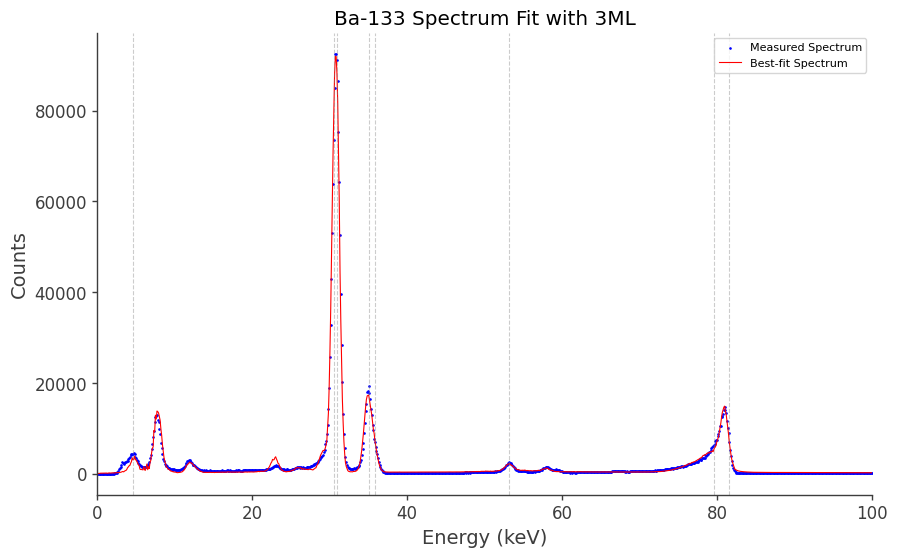

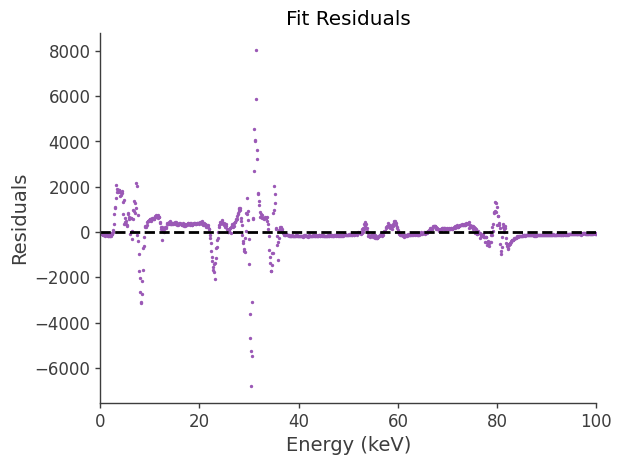

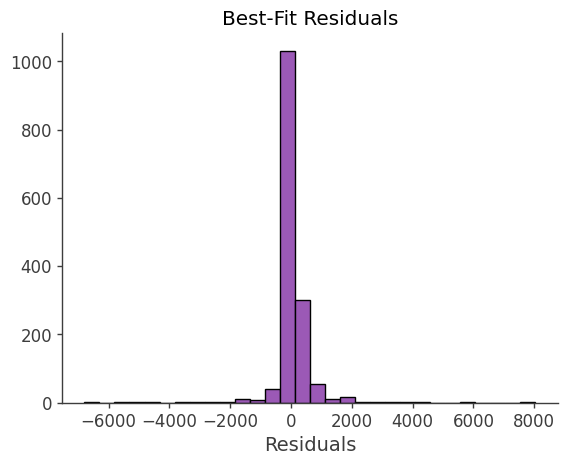

(                                                           value  \
 Ba133_Source_Spectrum.spectrum.main.composite.k_1       2.852332   
 Ba133_Source_Spectrum.spectrum.main.composite.F_2   10384.640286   
 Ba133_Source_Spectrum.spectrum.main.composite.mu_2      7.259426   
 Ba133_Source_Spectrum.spectrum.main.composite.s...      0.009163   
 Ba133_Source_Spectrum.spectrum.main.composite.F_3      49.703159   
 Ba133_Source_Spectrum.spectrum.main.composite.mu_3     29.333671   
 Ba133_Source_Spectrum.spectrum.main.composite.s...      0.024668   
 Ba133_Source_Spectrum.spectrum.main.composite.F_4     762.546832   
 Ba133_Source_Spectrum.spectrum.main.composite.mu_4     31.023860   
 Ba133_Source_Spectrum.spectrum.main.composite.s...      0.001740   
 Ba133_Source_Spectrum.spectrum.main.composite.F_5      94.463394   
 Ba133_Source_Spectrum.spectrum.main.composite.mu_5     35.123980   
 Ba133_Source_Spectrum.spectrum.main.composite.s...      0.006795   
 Ba133_Source_Spectrum.spectrum.ma

In [30]:
fit_spec(event_list,
         hist=hist,
         rsp=rsp,
         int_time=1740*u.s,
         initial_background=1.0,
         plot_fit=True,
         plot_residuals=True)

Re-examine the source model. I am modeling an idealized Ba133 source, as closely as possible (threeML cannot support delta function lines in the model, hence, the very think Gaussians instead).

The source spectrum is then convolved with / folded through the RMF (i.e. 
obs_spectrum = BinnedSpectrumWithDispersion(...)), such that the modeled curve (red) can be compared with the measured results (blue). 

Use threeML’s DispersionSpectrumLike(...) to compute the statistics between the best-fit model and the data.

Problem: the idealized source spectrum assumes that: 
1. The line energies are exact exact and have extremely narrow widths (0.01 keV).
2. That the response characterization is perfect. There are discrepancies in the real-world data, however. 
- The response matrix may be slightly miscalibrated (energy scale offset of a few tenths of a keV).
- The detector energy resolution in the RMF may not perfectly describe the actual line broadening.
- Background or nearby blended peaks may slightly skew the line shape.

If the centroids and widths of the lines are fixed, then the optimizer can only adjust the amplitudes of the peaks. 

This makes it nearly impossible for the fit to compensate for any small mismatches, hence the large residuals around strong peaks, and the sampler throwing away a majority of samples because parameter constraints (bounds or likelihood minima) are too tight.

07:53:21 INFO      Auto-probed noise models:                                                    ]8;id=371552;file:///Users/labadmin/opt/anaconda3/envs/threeml_py310/lib/python3.10/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=77870;file:///Users/labadmin/opt/anaconda3/envs/threeml_py310/lib/python3.10/site-packages/threeML/plugins/SpectrumLike.py#490\490]8;;\

         INFO      - observation: gaussian                                                      ]8;id=47318;file:///Users/labadmin/opt/anaconda3/envs/threeml_py310/lib/python3.10/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=833138;file:///Users/labadmin/opt/anaconda3/envs/threeml_py310/lib/python3.10/site-packages/threeML/plugins/SpectrumLike.py#491\491]8;;\

         INFO      - background: None                                                           ]8;id=28202;file:///Users/labadmin/opt/anaconda3/envs/threeml_py310/lib/python3.10/site-packages/threeML/plugins/SpectrumLike.py\SpectrumLike.py]8;;\:]8;id=652144;file:///Users/labadmin/opt/anaconda3/envs/threeml_py310/lib/python3.10/site-packages/threeML/plugins/SpectrumLike.py#492\492]8;;\

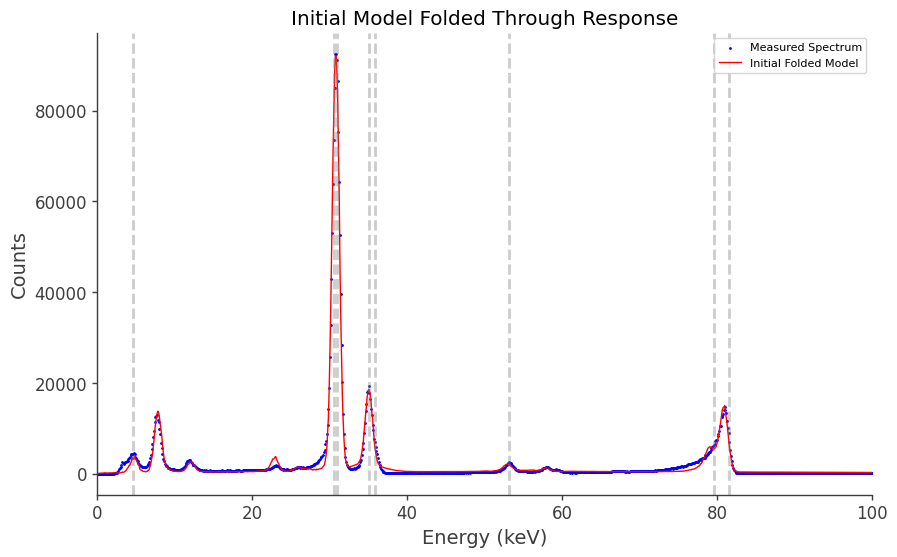

         INFO      set the minimizer to minuit                                             ]8;id=622918;file:///Users/labadmin/opt/anaconda3/envs/threeml_py310/lib/python3.10/site-packages/threeML/classicMLE/joint_likelihood.py\joint_likelihood.py]8;;\:]8;id=625429;file:///Users/labadmin/opt/anaconda3/envs/threeml_py310/lib/python3.10/site-packages/threeML/classicMLE/joint_likelihood.py#1046\1046]8;;\

07:53:28 WARNING   94.6 percent of samples have been thrown away because they failed the   ]8;id=969581;file:///Users/labadmin/opt/anaconda3/envs/threeml_py310/lib/python3.10/site-packages/threeML/analysis_results.py\analysis_results.py]8;;\:]8;id=697787;file:///Users/labadmin/opt/anaconda3/envs/threeml_py310/lib/python3.10/site-packages/threeML/analysis_results.py#1739\1739]8;;\
                  constraints on the parameters. This results might not be suitable for                            
                  error propagation. Enlarge the boundaries until you loose less than 1                            
                  percent of the samples.                                                                          

07:53:28 WARNING   The current value of the parameter mu_3 (0.0) was below the new minimum 20.6.   ]8;id=691294;file:///Users/labadmin/opt/anaconda3/envs/threeml_py310/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=260245;file:///Users/labadmin/opt/anaconda3/envs/threeml_py310/lib/python3.10/site-packages/astromodels/core/parameter.py#720\720]8;;\

         WARNING   The current value of the parameter mu_4 (0.0) was below the new minimum 21.0.   ]8;id=51541;file:///Users/labadmin/opt/anaconda3/envs/threeml_py310/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=213536;file:///Users/labadmin/opt/anaconda3/envs/threeml_py310/lib/python3.10/site-packages/astromodels/core/parameter.py#720\720]8;;\

         WARNING   The current value of the parameter mu_5 (0.0) was below the new minimum 25.1.   ]8;id=48095;file:///Users/labadmin/opt/anaconda3/envs/threeml_py310/lib/python3.10/site-packages/astromodels/core/parameter.py\parameter.py]8;;\:]8;id=676909;file:///Users/labadmin/opt/anaconda3/envs/threeml_py310/lib/python3.10/site-packages/astromodels/core/parameter.py#720\720]8;;\

...

Values of -log(likelihood) at the minimum:

,-log(likelihood)
Ba133_Measured_Spectrum,48.299758
total,48.299758


Values of statistical measures:

,statistical measures
AIC,147.481470
BIC,279.430026



Best-fit parameters (keV and counts units):

ba133_source.position.ra       = 0.0 deg
ba133_source.position.dec      = 0.0 deg
ba133_source.spectrum.main.composite.k_1 = 2.026 1 / (keV s cm2)
ba133_source.spectrum.main.composite.F_2 = 235.2 ± 0.0 counts
ba133_source.spectrum.main.composite.mu_2 = 9.70 ± 0.00 keV
ba133_source.spectrum.main.composite.sigma_2 = 4.999919976674763 keV
ba133_source.spectrum.main.composite.F_3 = 128.0 ± 0.0 counts
ba133_source.spectrum.main.composite.mu_3 = 30.02 ± 0.00 keV
ba133_source.spectrum.main.composite.sigma_3 = 1.241142129146198 keV
ba133_source.spectrum.main.composite.F_4 = 999.7 ± 0.0 counts
ba133_source.spectrum.main.composite.mu_4 = 31.07 ± 0.00 keV
ba133_source.spectrum.main.composite.sigma_4 = 0.040646239081463545 keV
ba133_source.spectrum.main.composite.F_5 = 71.4 ± 0.0 counts
ba133_source.spectrum.main.composite.mu_5 = 35.87 ± 0.00 keV
ba133_source.spectrum.main.composite.sigma_5 = 0.3671993887794462 keV
ba133_source.spectrum.main.composite.

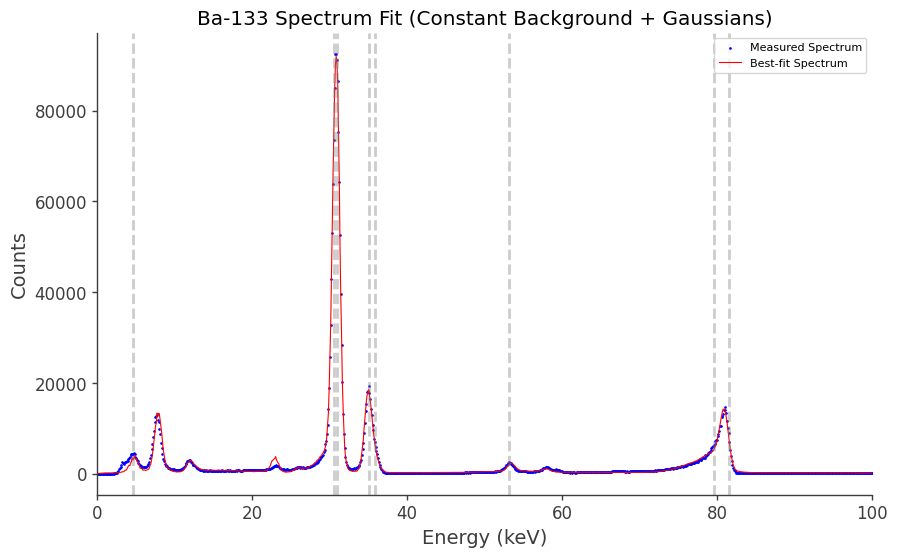

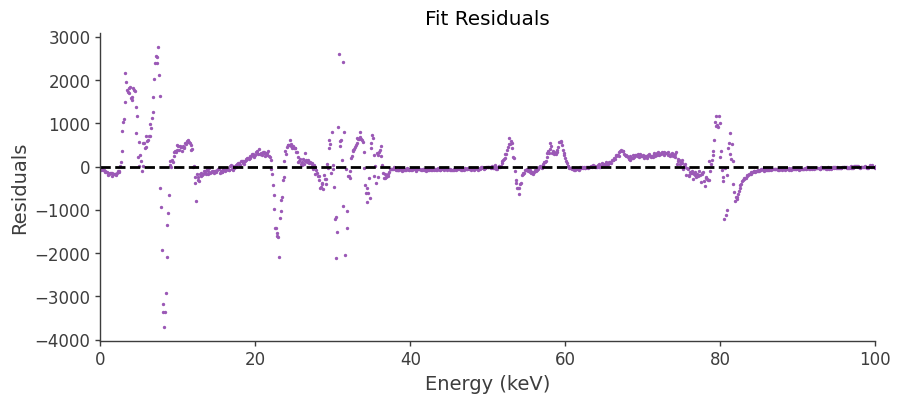

In [ ]:
def fit_spec(event_list, hist, rsp, int_time, initial_background,
             plot_fit=False, plot_residuals=False):

    # ----- 1. Compute bin centers -----
    num_bins = rsp.matrix.shape[0]
    e_min = rsp.monte_carlo_energies[0]
    e_max = rsp.monte_carlo_energies[-1]
    bin_edges = np.linspace(e_min, e_max, num_bins + 1)
    bin_centers = 0.5 * (bin_edges[1:] + bin_edges[:-1])

    # ----- 2. Observed spectrum -----
    obs_spectrum = BinnedSpectrumWithDispersion(
        counts=hist,
        exposure=float(int_time.value),
        response=rsp,
    )
    obs_spectrum._errors = np.ones_like(hist)  # placeholder for errors

    plugin = DispersionSpectrumLike(
        name="Ba133_Measured_Spectrum",
        observation=obs_spectrum,
        background=None,
        verbose=False
    )

    # ----- 3. Constant background -----
    background = Constant()
    background.k.value = initial_background
    background.k.free = True

    # ----- 4. Ba-133 gamma lines -----
    ba133_lines_keV = np.array([4.7, 30.6, 31.0, 35.1, 35.9, 53.2, 79.6, 81.5])
    ba133_intensities = np.array([15.87, 33.8, 62.4, 18.24, 4.45, 2.14, 2.63, 33.31]) / 100.0

    total_counts = np.sum(hist) if np.sum(hist) > 0 else 1.0
    rough_efficiency = 0.1
    ba133_int_counts = ba133_intensities * total_counts * rough_efficiency

    # ----- 5. Build full model with Gaussians -----
    composite_spectrum = background
    components = []

    for i, E in enumerate(ba133_lines_keV):
        g = Gaussian()

        # Flux initialization from ±1 bin around line
        bin_idx = np.argmin(np.abs(bin_centers - E))
        idx_min = max(bin_idx - 2, 0)
        idx_max = min(bin_idx + 3, len(hist))
        F_init = max(np.sum(hist[idx_min:idx_max]), 10.)

        g.mu.value = E
        g.sigma.value = 0.5
        g.F.value = F_init
        
        g.mu.bounds = (E - 10.0, E + 10.0)
        g.mu.free = True

        g.sigma.bounds = (0.01, 5.0)
        g.sigma.free = True

        g.F.bounds = (0, 20 * F_init)
        g.F.free = True

        components.append(g)
        composite_spectrum += g

    # ----- 6. Full source and model -----
    source = PointSource("ba133_source", ra=0, dec=0, spectral_shape=composite_spectrum)
    model = Model(source)



    # ----- After creating model -----
    for i, E in enumerate(ba133_lines_keV):
        par_mu_name = f"ba133_source.spectrum.main.composite.mu_{i+2}"
        model.parameters[par_mu_name].value = E
        model.parameters[par_mu_name].free = True

        par_sigma_name = f"ba133_source.spectrum.main.composite.sigma_{i+2}"
        model.parameters[par_sigma_name].value = 0.5
        model.parameters[par_sigma_name].free = True

        par_F_name = f"ba133_source.spectrum.main.composite.F_{i+2}"
        bin_idx = np.argmin(np.abs(bin_centers - E))
        idx_min = max(bin_idx - 2, 0)
        idx_max = min(bin_idx + 3, len(hist))
        F_init = max(np.sum(hist[idx_min:idx_max]), 10.)
        model.parameters[par_F_name].value = F_init
        model.parameters[par_F_name].bounds = (0, 3*F_init)
        model.parameters[par_F_name].free = True

    # ----- 7. Quick-look folded model plot -----
    if plot_fit:
        model_counts = plugin.get_model()
        plt.figure(figsize=(10,6))
        plt.scatter(bin_centers, hist, c='blue', s=1.0, label='Measured Spectrum')
        plt.plot(bin_centers, model_counts, color='red', linewidth=1.0, label='Initial Folded Model')
        for e in ba133_lines_keV:
            plt.axvline(e, color='gray', linestyle='--', alpha=0.4)
        plt.xlabel('Energy (keV)')
        plt.ylabel('Counts')
        plt.title('Initial Model Folded Through Response')
        plt.xlim(0, 100)
        plt.legend()
        plt.show()

    # ----- 8. Fit -----
    data_list = DataList(plugin)
    jl = JointLikelihood(model, data_list)
    fit_result = jl.fit(quiet=False)

    # ----- 9. Print clean best-fit table -----
    print("\nBest-fit parameters (keV and counts units):\n")
    for par in model.parameters:
        val = model.parameters[par].value
        err = getattr(model.parameters[par], "uncertainty", 0)
        unit = model.parameters[par].unit or ""
        # Print mu in keV, F in counts
        if "mu" in par:
            print(f"{par:30s} = {val:.2f} ± {err:.2f} keV")
        elif "F" in par:
            print(f"{par:30s} = {val:.1f} ± {err:.1f} counts")
        elif "k" in par:
            print(f"{par:30s} = {val:.3f} {unit}")
        else:
            print(f"{par:30s} = {val} {unit}")

    # ----- 10. Optional: MCMC sampling -----
    if hasattr(jl, "sample"):
        print("\n➡ Running Bayesian sampling...")
        fit_result = jl.sample("emcee", nwalkers=50, burn_in=200, steps=1000)
        model_counts = plugin.get_model()

    # ----- 11. Best-fit plot -----
    if plot_fit:
        plt.figure(figsize=(10,6))
        plt.scatter(bin_centers, hist, c='blue', s=0.8, label="Measured Spectrum")
        plt.plot(bin_centers, plugin.get_model(), color='red', linewidth=0.8, label="Best-fit Spectrum")
        for e in ba133_lines_keV:
            plt.axvline(e, color='gray', linestyle='--', alpha=0.4)
        plt.xlabel("Energy (keV)")
        plt.ylabel("Counts")
        plt.title("Ba-133 Spectrum Fit (Constant Background + Gaussians)")
        plt.xlim(0, 100)
        plt.legend()
        plt.show()

    # ----- 12. Residuals -----
    if plot_residuals:
        residuals = hist - plugin.get_model()
        plt.figure(figsize=(10,4))
        plt.scatter(bin_centers, residuals, s=2.0)
        plt.axhline(0, color='black', linestyle='--')
        plt.xlabel('Energy (keV)')
        plt.ylabel('Residuals')
        plt.title('Fit Residuals')
        plt.xlim(0, 100)
        plt.show()

    return fit_result

# ----- Call fit -----
fit_result = fit_spec(
    event_list,
    hist=hist,
    rsp=rsp,
    int_time=1740*u.s,
    initial_background=1.0,
    plot_fit=True,
    plot_residuals=True
)

The fit looks well visually. There are features in the measured spectrum that are not in the fit, which is to be expected. The Ba133 source that was measured was placed outside the vacuum chamber. There are several elements in the optical path of the xrays, between them and the detectors. Secondary x-rays from Au, Ag, Pt, Pb, Al, Be, Fe, W will be present in the data. I suggest trying this again, using the spectrum generated by the calibration sources, in-flight. 